# Phase I: Dataset Generation Pipeline

This notebook implements the full dataset generation pipeline:

1. **Load Raw TIF Volumes**
2. **Preprocessing** (Denoising & Enhancement)
3. **ROI Sampling / Set-of-Marks Prompting** (Grid Overlay on 2D Slices)
4. **Initial Segmentation** (Automatic Segmentation)
5. **Gemini API** (Grid Square Identification via LMM)
6. **MedSAM** (Unsupervised Automatic Segmentation)
7. **Human-in-the-Loop** (Napari Viewer for Verification & Correction)
8. **Export Final Ground-Truth Dataset**

## 0. Setup & Dependencies

In [1]:
%pip install scikit-image pywavelets napari google-generativeai tifffile matplotlib numpy pillow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\bkrou\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, exposure, filters, morphology
from skimage.restoration import denoise_wavelet
import tifffile

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "image.cmap": "gray",
})

## 1. Configuration — Set Your Image Path Here

In [3]:
import os

# ============================================================
# >>> SET YOUR IMAGE PATH HERE <<<
# ============================================================
IMAGE_PATH = Path("tifs/F08_1_20240817_roi3_Red.tif")  # <-- EDIT THIS
# ============================================================
# Output directory for results
OUTPUT_DIR = Path("output/phase1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Gemini API key (set via environment variable or paste here)
GEMINI_API_KEY = os.getenv("GEMINI_KEY")  # or "your-api-key-here"

print(f"Image path: {IMAGE_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Image path: tifs\F08_1_20240817_roi3_Red.tif
Output directory: output\phase1


## 2. Load Raw TIF Volume

In [4]:
def load_volume(path: Path) -> np.ndarray:
    """Load a 3D microscopy volume from disk as float32."""
    volume = io.imread(path).astype(np.float32)
    return volume


def volume_stats(volume: np.ndarray) -> dict:
    """Compute basic statistics for a volume."""
    return {
        "shape": volume.shape,
        "dtype": str(volume.dtype),
        "min": float(volume.min()),
        "max": float(volume.max()),
        "mean": float(volume.mean()),
        "std": float(volume.std()),
    }


# Load the volume
raw_volume = load_volume(IMAGE_PATH)
print("Raw volume loaded:")
for k, v in volume_stats(raw_volume).items():
    print(f"  {k}: {v}")

Raw volume loaded:
  shape: (60, 1024, 1024)
  dtype: float32
  min: -256.0
  max: 7638.0
  mean: 138.57144165039062
  std: 119.48974609375


## 3. Preprocessing (Denoising & Enhancement)

In [5]:
def preprocess_volume(volume: np.ndarray,
                      wavelet_sigma: float = 0.001,
                      clip_limit: float = 0.03,
                      kernel_size: tuple = (32, 32, 8)) -> tuple[np.ndarray, np.ndarray]:
    """
    Apply wavelet denoising and adaptive histogram equalization.
    
    Returns:
        denoised: Wavelet-denoised volume
        enhanced: After adaptive histogram equalization
    """
    # Wavelet denoising
    denoised = denoise_wavelet(
        volume,
        mode="soft",
        wavelet_levels=None,
        wavelet="db2",
        rescale_sigma=True,
        sigma=wavelet_sigma,
    )
    
    # Adaptive histogram equalization
    rescaled = exposure.rescale_intensity(denoised, in_range="image", out_range=(0.0, 1.0))
    enhanced = exposure.equalize_adapthist(rescaled, kernel_size=kernel_size, clip_limit=clip_limit)
    
    return denoised, enhanced

Preprocessing complete.
  Denoised range: [-256.00, 7638.00]
  Enhanced range: [0.00, 1.00]


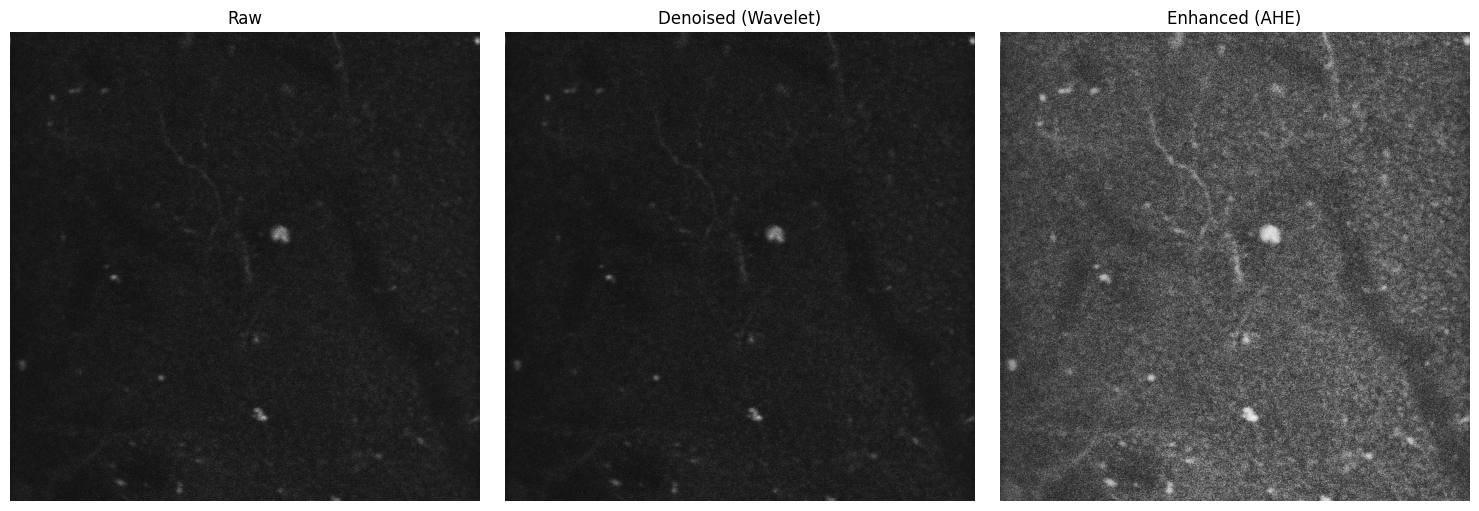

In [6]:
# Run preprocessing
denoised_volume, enhanced_volume = preprocess_volume(raw_volume)

print("Preprocessing complete.")
print(f"  Denoised range: [{denoised_volume.min():.2f}, {denoised_volume.max():.2f}]")
print(f"  Enhanced range: [{enhanced_volume.min():.2f}, {enhanced_volume.max():.2f}]")

# Visualize central slice
z_mid = raw_volume.shape[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(raw_volume[z_mid], cmap="gray")
axes[0].set_title("Raw")
axes[1].imshow(denoised_volume[z_mid], cmap="gray")
axes[1].set_title("Denoised (Wavelet)")
axes[2].imshow(enhanced_volume[z_mid], cmap="gray")
axes[2].set_title("Enhanced (AHE)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

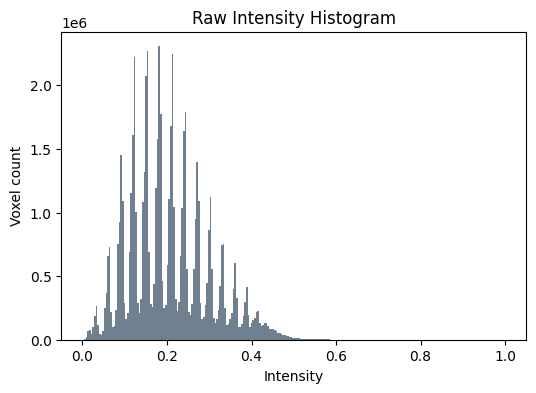

In [7]:
plt.figure(figsize=(6, 4))
plt.hist(enhanced_volume.ravel(), bins=256, color="slategray")
plt.title("Raw Intensity Histogram")
plt.xlabel("Intensity")
plt.ylabel("Voxel count")
plt.show()
    

## 4. ROI Sampling / Set-of-Marks Prompting (Grid Overlay)

In [8]:
def create_grid_overlay(image: np.ndarray, grid_size: tuple[int, int] = (8, 8)) -> tuple[np.ndarray, list[dict]]:
    """
    Create a grid overlay on a 2D image for set-of-marks prompting.
    
    Args:
        image: 2D image array
        grid_size: (rows, cols) for the grid
    
    Returns:
        overlay_image: RGB image with grid overlay and labels
        grid_cells: List of dicts with cell info (label, bounds, center)
    """
    h, w = image.shape[:2]
    rows, cols = grid_size
    cell_h, cell_w = h // rows, w // cols
    
    # Normalize image to 0-255 for RGB conversion
    img_norm = ((image - image.min()) / (image.max() - image.min() + 1e-8) * 255).astype(np.uint8)
    overlay = np.stack([img_norm, img_norm, img_norm], axis=-1)
    
    grid_cells = []
    
    for r in range(rows):
        for c in range(cols):
            y1, y2 = r * cell_h, (r + 1) * cell_h
            x1, x2 = c * cell_w, (c + 1) * cell_w
            
            # Draw grid lines (red)
            overlay[y1, x1:x2] = [255, 0, 0]
            overlay[y1:y2, x1] = [255, 0, 0]
            if r == rows - 1:
                overlay[min(y2, h-1), x1:x2] = [255, 0, 0]
            if c == cols - 1:
                overlay[y1:y2, min(x2, w-1)] = [255, 0, 0]
            
            # Store cell info
            label = f"{chr(65 + r)}{c + 1}"  # A1, A2, ..., B1, B2, ...
            grid_cells.append({
                "label": label,
                "bounds": (y1, y2, x1, x2),
                "center": ((y1 + y2) // 2, (x1 + x2) // 2),
            })
    
    return overlay, grid_cells


def extract_grid_rois(volume: np.ndarray, slice_indices: list[int], grid_size: tuple[int, int] = (8, 8)) -> list[dict]:
    """
    Extract grid ROIs from multiple slices for prompting.
    
    Returns:
        List of dicts with slice_idx, overlay_image, and grid_cells
    """
    results = []
    for z in slice_indices:
        overlay, cells = create_grid_overlay(volume[z], grid_size)
        results.append({
            "slice_idx": z,
            "overlay": overlay,
            "grid_cells": cells,
        })
    return results

Generated grid overlays for 5 slices
Grid size: 8x8 = 64 cells per slice


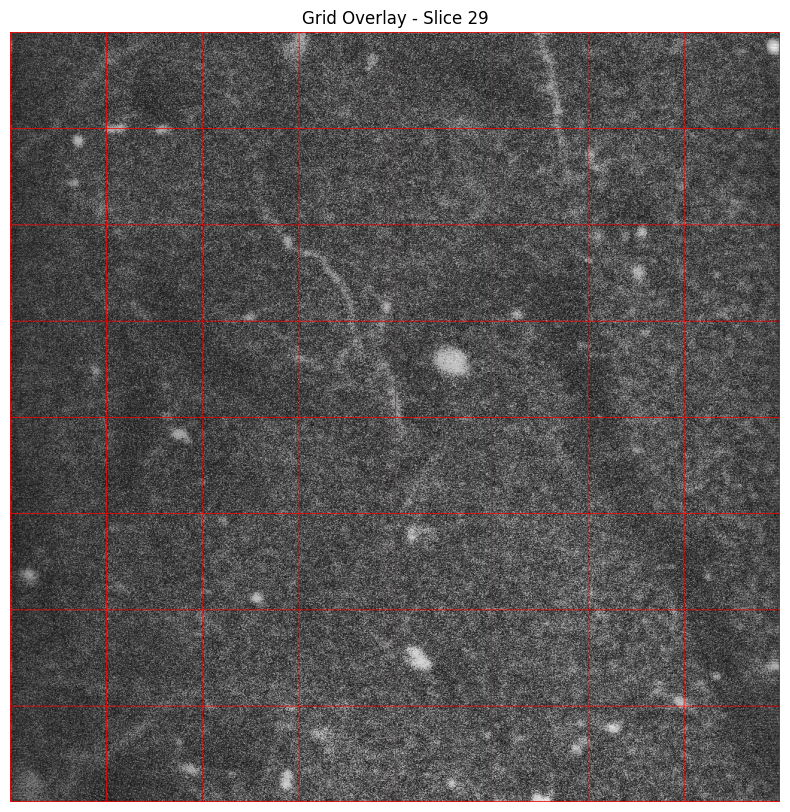

In [9]:
# Generate grid overlays for selected slices
n_slices = min(5, raw_volume.shape[0])
slice_indices = np.linspace(0, raw_volume.shape[0] - 1, n_slices, dtype=int).tolist()
grid_size = (8, 8)

grid_rois = extract_grid_rois(enhanced_volume, slice_indices, grid_size)

print(f"Generated grid overlays for {len(grid_rois)} slices")
print(f"Grid size: {grid_size[0]}x{grid_size[1]} = {grid_size[0] * grid_size[1]} cells per slice")

# Visualize one example
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(grid_rois[len(grid_rois)//2]["overlay"])
ax.set_title(f"Grid Overlay - Slice {grid_rois[len(grid_rois)//2]['slice_idx']}")
ax.axis("off")
plt.show()

## 5. Initial Segmentation (Automatic)

In [10]:
def automatic_segmentation(volume: np.ndarray, block_size: int = 51, offset: float = -0.01) -> np.ndarray:
    """
    Perform automatic segmentation using adaptive thresholding.
    
    Args:
        volume: 3D preprocessed volume
        block_size: Local neighborhood size (must be odd)
        offset: Threshold offset (negative = more foreground)
    
    Returns:
        Binary mask
    """
    mask = np.zeros_like(volume, dtype=bool)
    
    for z in range(volume.shape[0]):
        slice_img = volume[z]
        local_thresh = filters.threshold_local(slice_img, block_size=block_size, method="gaussian", offset=offset)
        mask[z] = slice_img > local_thresh
    
    return mask


def refine_mask(mask: np.ndarray, min_size: int = 5000, closing_radius: int = 2) -> np.ndarray:
    """
    Refine binary mask with morphological operations.
    """
    # Remove small objects
    cleaned = morphology.remove_small_objects(mask, min_size=min_size)
    # Close gaps
    closed = morphology.binary_closing(cleaned, morphology.ball(closing_radius))
    # Smooth edges
    refined = morphology.binary_opening(closed, morphology.ball(1))
    return refined

Initial mask voxels: 26,401,187
Refined mask voxels: 59,481,745


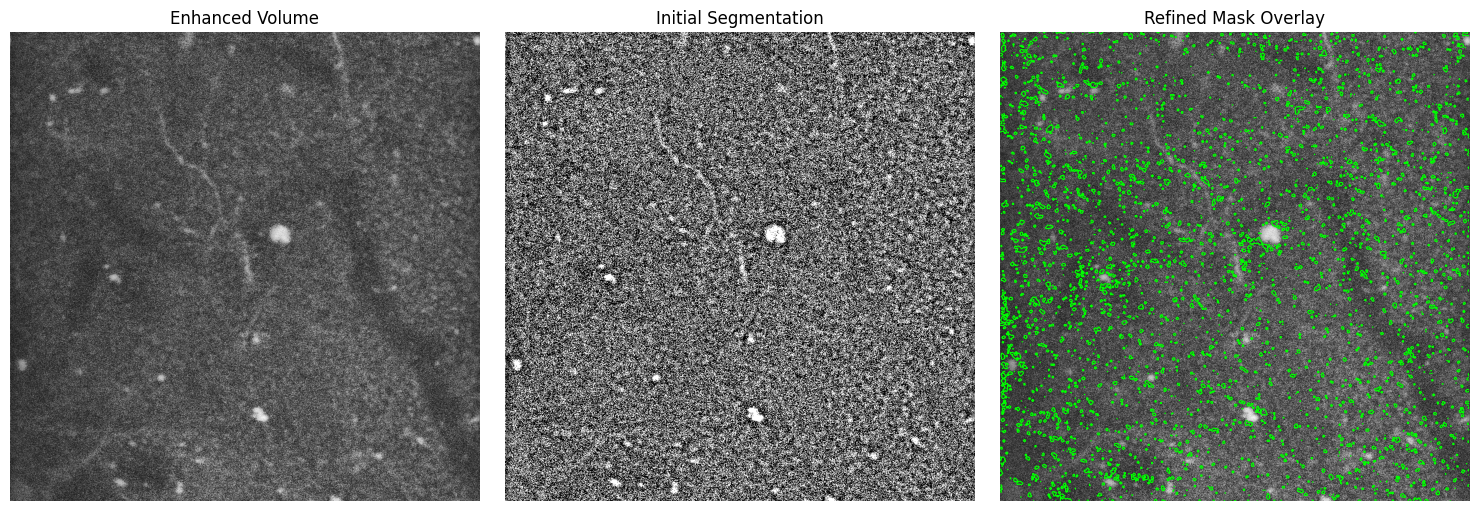

In [11]:
# Run automatic segmentation
initial_mask = automatic_segmentation(enhanced_volume)
refined_mask = refine_mask(initial_mask)

print(f"Initial mask voxels: {initial_mask.sum():,}")
print(f"Refined mask voxels: {refined_mask.sum():,}")

# Visualize
z_mid = raw_volume.shape[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(enhanced_volume[z_mid], cmap="gray")
axes[0].set_title("Enhanced Volume")
axes[1].imshow(initial_mask[z_mid], cmap="gray")
axes[1].set_title("Initial Segmentation")
axes[2].imshow(enhanced_volume[z_mid], cmap="gray")
axes[2].contour(refined_mask[z_mid], colors="lime", linewidths=0.8)
axes[2].set_title("Refined Mask Overlay")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Gemini API (Grid Square Identification via LMM)

In [16]:
import os
import io as io_module
from PIL import Image
import base64

def setup_gemini(api_key: str | None = None):
    """Initialize Gemini API client."""
    import google.generativeai as genai
    
    key = api_key or os.environ.get("GEMINI_API_KEY")
    if not key:
        raise ValueError("Gemini API key not found. Set GEMINI_API_KEY or pass api_key.")
    
    genai.configure(api_key=key)
    return genai.GenerativeModel("gemini-2.5-flash")


def query_gemini_for_spines(model, overlay_image: np.ndarray, grid_cells: list[dict]) -> dict:
    """
    Query Gemini to identify grid squares containing dendritic spines.
    
    Returns:
        Dict with 'spine_cells' (list of labels) and 'raw_response'
    """
    cell_labels = [c["label"] for c in grid_cells]
    
    prompt = f"""This is a microscopy image of a dendritic shaft with a grid overlay.
The grid cells are labeled: {', '.join(cell_labels[:16])}... (continuing to {cell_labels[-1]}).

Please identify which grid squares contain dendritic spines (small protrusions from the main shaft).
Return ONLY a comma-separated list of grid cell labels (e.g., "A3, B5, C2").
If no spines are visible, return "NONE"."""
    
    # Convert image for API
    img_pil = Image.fromarray(overlay_image.astype(np.uint8))
    
    response = model.generate_content([prompt, img_pil])
    response_text = response.text.strip()
    
    # Parse response
    if response_text.upper() == "NONE":
        spine_cells = []
    else:
        spine_cells = [s.strip() for s in response_text.split(",") if s.strip()]
    
    return {
        "spine_cells": spine_cells,
        "raw_response": response_text,
    }

In [17]:
# Run Gemini identification (skip if no API key)
gemini_results = []

if GEMINI_API_KEY:
    model = setup_gemini(GEMINI_API_KEY)
    
    for roi in grid_rois:
        result = query_gemini_for_spines(model, roi["overlay"], roi["grid_cells"])
        result["slice_idx"] = roi["slice_idx"]
        gemini_results.append(result)
        print(f"Slice {roi['slice_idx']}: Found spines in {len(result['spine_cells'])} cells")
else:
    print("Skipping Gemini API (no API key configured)")
    print("Set GEMINI_API_KEY in the Configuration cell to enable LMM-based identification.")

Slice 0: Found spines in 64 cells
Slice 14: Found spines in 14 cells
Slice 29: Found spines in 12 cells
Slice 44: Found spines in 19 cells
Slice 59: Found spines in 5 cells


## 7. MedSAM (Unsupervised Automatic Segmentation)

In [ ]:
# MedSAM placeholder - requires separate installation and model weights
# pip install git+https://github.com/bowang-lab/MedSAM.git

def run_medsam_segmentation(volume: np.ndarray, prompts: list[dict] | None = None) -> np.ndarray:
    """
    Run MedSAM segmentation on the volume.
    
    Args:
        volume: 3D preprocessed volume
        prompts: Optional list of point/box prompts from Gemini
    
    Returns:
        Segmentation mask
    """
    # TODO: Implement MedSAM integration
    # This requires:
    # 1. Download MedSAM model weights
    # 2. Initialize MedSAM model
    # 3. Run inference with optional prompts
    
    print("MedSAM integration placeholder")
    print("To enable, install MedSAM and download model weights.")
    
    # Return the refined mask as fallback
    return refined_mask


# Run MedSAM (placeholder)
medsam_mask = run_medsam_segmentation(enhanced_volume)

MedSAM integration placeholder
To enable, install MedSAM and download model weights.


## 8. Human-in-the-Loop (Napari Viewer)

In [ ]:
def launch_napari_viewer(volume: np.ndarray, mask: np.ndarray, name: str = "Volume"):
    """
    Launch Napari viewer for manual verification and correction.
    
    Returns:
        napari.Viewer instance (user can edit labels layer)
    """
    import napari
    
    viewer = napari.Viewer()
    viewer.add_image(volume, name=name)
    viewer.add_labels(mask.astype(np.int32), name="Segmentation (editable)")
    
    print("Napari viewer launched.")
    print("Instructions:")
    print("  - Use the Labels layer to correct segmentation")
    print("  - Press 'P' for paint mode, 'E' for erase mode")
    print("  - Close viewer when done to continue")
    
    return viewer


def get_corrected_mask(viewer) -> np.ndarray:
    """Extract the corrected mask from Napari viewer."""
    labels_layer = viewer.layers["Segmentation (editable)"]
    return labels_layer.data.astype(bool)

In [ ]:
# Launch Napari for manual correction
# Uncomment to run (opens interactive window)

# viewer = launch_napari_viewer(enhanced_volume, refined_mask)
# napari.run()  # Blocks until viewer is closed
# corrected_mask = get_corrected_mask(viewer)

# For now, use refined mask as final
final_mask = refined_mask
print("Using refined mask as final (uncomment Napari cell for manual correction)")

Using refined mask as final (uncomment Napari cell for manual correction)


## 9. Export Final Ground-Truth Dataset

In [ ]:
def export_ground_truth(volume: np.ndarray, mask: np.ndarray, output_dir: Path, name: str):
    """
    Export volume and mask as ground-truth dataset.
    
    Saves:
        - {name}_volume.tif: Preprocessed volume
        - {name}_mask.tif: Binary segmentation mask
        - {name}_metadata.npz: Additional metadata
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Save volume and mask
    tifffile.imwrite(output_dir / f"{name}_volume.tif", volume.astype(np.float32))
    tifffile.imwrite(output_dir / f"{name}_mask.tif", mask.astype(np.uint8))
    
    # Save metadata
    np.savez(
        output_dir / f"{name}_metadata.npz",
        shape=volume.shape,
        mask_voxels=mask.sum(),
        source_file=str(IMAGE_PATH),
    )
    
    print(f"Exported ground-truth to {output_dir}:")
    print(f"  - {name}_volume.tif")
    print(f"  - {name}_mask.tif")
    print(f"  - {name}_metadata.npz")

In [ ]:
# Export final ground-truth
sample_name = IMAGE_PATH.stem
export_ground_truth(enhanced_volume, final_mask, OUTPUT_DIR, sample_name)

print(f"\n✓ Pipeline complete for {sample_name}")
print(f"  Volume shape: {enhanced_volume.shape}")
print(f"  Mask voxels: {final_mask.sum():,}")

Exported ground-truth to output\phase1:
  - F08_1_20240817_roi3_Red_volume.tif
  - F08_1_20240817_roi3_Red_mask.tif
  - F08_1_20240817_roi3_Red_metadata.npz

✓ Pipeline complete for F08_1_20240817_roi3_Red
  Volume shape: (60, 1024, 1024)
  Mask voxels: 59,481,745


## 10. Batch Processing (Optional)

In [ ]:
def process_batch(input_dir: Path, output_dir: Path, pattern: str = "*.tif"):
    """
    Process multiple volumes through the pipeline.
    
    Note: For batch processing, Napari step is skipped (use for initial pass,
    then review/correct individual volumes as needed).
    """
    tif_files = list(input_dir.glob(pattern))
    print(f"Found {len(tif_files)} files to process")
    
    for i, tif_path in enumerate(tif_files):
        print(f"\n[{i+1}/{len(tif_files)}] Processing {tif_path.name}...")
        
        # Load
        vol = load_volume(tif_path)
        
        # Preprocess
        _, enhanced = preprocess_volume(vol)
        
        # Segment
        mask = automatic_segmentation(enhanced)
        mask = refine_mask(mask)
        
        # Export
        export_ground_truth(enhanced, mask, output_dir, tif_path.stem)
    
    print(f"\n✓ Batch processing complete. Processed {len(tif_files)} volumes.")


# Example batch processing (uncomment to run):
# process_batch(Path("train_data"), OUTPUT_DIR / "batch")